## ⚠️ Dependency Note

This notebook assumes that `01_setup_data.ipynb` has been executed
in the same Python session.

The setup notebook defines:
- Data loading 
- Metadata information (variable types and levels)
- Shared configuration variables

If running this notebook independently, please execute
`01_setup_data.ipynb` first.

In [0]:
# Scenario 3: nonlinear heterogeneous treatment effect, unmeasured confounding function, moderate overlap function
def treatment_effect_fn(X, index):
    cvd_pre, age, Charlson, dementia_pre = index.slice(X, "cvd_pre", "age", "Charlson", "dementia_pre", unbind=True)
    # X is a torch.Tensor of features excluding 
    return 0.02 + 0.05*torch.tanh(0.4*cvd_pre + 0.2*age + 0.2*Charlson + 0.4*dementia_pre) #+ Charlson
    # mse weight: 03-0.4, 0.1-0.2; var weight: 2e-1, 2e-2


def selection_bias_fn(X, T, index):
    # latent risk constructed from observable X
    cvd_pre, age, Charlson= index.slice(X, "cvd_pre", "age",  "Charlson", unbind=True)
    U = 0.5*Charlson + 0.6*cvd_pre + 0.2*age
    return 0.05-0.01*(2*T-1)*torch.tanh(U)

# the following functions were tried but not used due to low performance
# def treatment_effect_fn(X, index):
#     cvd_pre, age= index.slice(X, "cvd_pre", "age", unbind=True)
#     # X is a torch.Tensor of features excluding 
#     bump = torch.exp(0.5*age)
#     return 0.02+0.02* bump #+ 0.02*(2*cvd_pre-1)
    # results: bimodal cate distribution wasn't achieved if using both cvd_pre and age; using age only may get bins plots

# def selection_bias_fn(X, T, index):
#     # latent risk constructed from observable X
#     return 0.2*(2*T-1)
#     # results: the selection bias is not achieved, with the average confounding of 0.

# def selection_bias_fn(X, T, index):
#     # latent risk constructed from observable X
#     cvd_pre = index.slice(X, "cvd_pre")
#     #cvd_pre = X[:, 7]
#     # Ensure T and cvd_pre are both 1D before multiplication
#     # T_flat = T.flatten() if hasattr(T, 'flatten') else T.ravel()
#     # cvd_pre_flat = cvd_pre.flatten() if hasattr(cvd_pre, 'flatten') else cvd_pre.ravel()
#     # result = 0.1*(2*T_flat-1)*cvd_pre_flat
#     # return result
#     return 0.02*(2*T-1) *cvd_pre
    # results: the selection bias is not achieved

def overlap_fn(X, index):
    Abiraterone_prev = index.slice(X, "Abiraterone_prev")
    return 2*(2*Abiraterone_prev-1)

m3 = CausalMix(
    data = mcrpc_data,  
    post_treatment_var = ["hosp_ed_any"],  
    treatment_var = ["exp"],  
    binary_var = binary_var, 
    categorical_var = categorical_var,  
    numerical_var = numerical_var,  
    integer_var = numerical_var, 
    categorical_dims=unique_levels,      
    var_bounds={},  
)

m3.fit(
    treatment_effect_fn=treatment_effect_fn,
    selection_bias_fn=selection_bias_fn,
    overlap_target=overlap_fn,
    effect_rigidity=1e3,
    effect_mse_weight=0.4, # effect blend weight on MSE
    effect_var_weight=2e-1, # variance penalty for treatment effect residuals
    bias_rigidity=1e3,
    bias_mse_weight=0.2, # bias blend weight on MSE
    bias_var_weight=2e-2, # variance penalty for bias residuals
    overlap_weight = 1e1,
    kld_rigidity=0.1
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │  1.2 K │ train │     0 │
│ 1 │ en_mu        │ Linear     │  1.2 K │ train │     0 │
│ 2 │ en_logvar    │ Linear     │  1.2 K │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.3 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │  1.5 K │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │  1.2 K │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 7.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/util

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder      │ Sequential │    128 │ train │     0 │
│ 1 │ en_mu        │ Linear     │    130 │ train │     0 │
│ 2 │ en_logvar    │ Linear     │    130 │ train │     0 │
│ 3 │ decoder      │ Sequential │  1.4 K │ train │     0 │
│ 4 │ output_heads │ ModuleDict │    130 │ train │     0 │
│ 5 │ var_heads    │ ModuleDict │    130 │ train │     0 │
└───┴──────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 2.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/local_disk0/.ephemeral_nfs/cluster_libraries/python/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: PossibleUserWarning:

The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.



[exp    0.570278
 dtype: float64,
 conVAE(
   (encoder): Sequential(
     (0): Sequential(
       (0): Linear(in_features=18, out_features=64, bias=True)
       (1): LeakyReLU(negative_slope=0.01)
     )
   )
   (en_mu): Linear(in_features=64, out_features=18, bias=True)
   (en_logvar): Linear(in_features=64, out_features=18, bias=True)
   (decoder): Sequential(
     (0): Sequential(
       (0): Linear(in_features=19, out_features=64, bias=True)
       (1): LeakyReLU(negative_slope=0.01)
     )
   )
   (output_heads): ModuleDict(
     (0): Linear(in_features=64, out_features=1, bias=True)
     (1): Linear(in_features=64, out_features=1, bias=True)
     (2): Linear(in_features=64, out_features=1, bias=True)
     (3): Linear(in_features=64, out_features=1, bias=True)
     (4): Linear(in_features=64, out_features=1, bias=True)
     (5): Linear(in_features=64, out_features=1, bias=True)
     (6): Linear(in_features=64, out_features=1, bias=True)
     (7): Linear(in_features=64, out_feature

In [0]:
# Last logged validation loss from the final epoch
last_val_X = m3.m_pre.trainer.callback_metrics.get("val_loss")
print("Last val_loss for X:", float(last_val_X) if last_val_X is not None else "N/A")
last_val_Y = m3.m_post.trainer.callback_metrics.get("val_loss")
print("Last val_loss for Y:", float(last_val_Y) if last_val_Y is not None else "N/A")

Last val_loss for X: 1.2398985624313354
Last val_loss for Y: 0.17131350934505463


Overlap metrics: {'dec/log_ratio_mean': -0.19, 'dec/log_ratio_std': 1.955, 'dec/target_mean': -0.199, 'dec/target_std': 1.99, 'dec/mse_to_target': 0.005, 'dec/fraction_within_tol': 0.997, 'ps/auc': 0.893, 'ps/hist_overlap_coeff': 0.237, 'ps/frac_common_support': 0.999, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 0.999}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


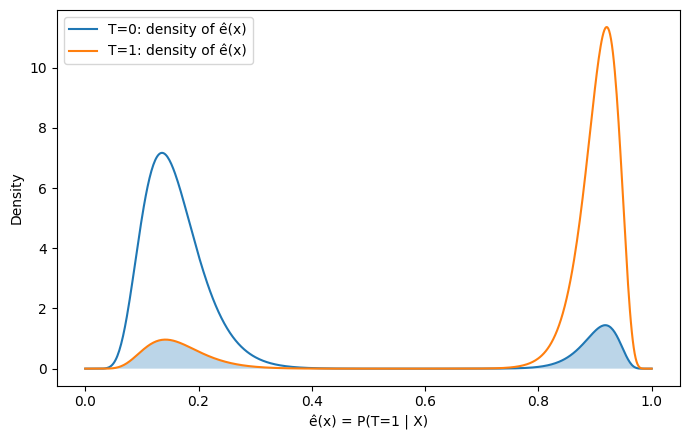

Overlap metrics: {'dec/log_ratio_mean': -0.198, 'dec/log_ratio_std': 2.046, 'dec/target_mean': -0.161, 'dec/target_std': 1.994, 'dec/mse_to_target': 0.458, 'dec/fraction_within_tol': 0.93, 'ps/auc': 0.863, 'ps/hist_overlap_coeff': 0.298, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


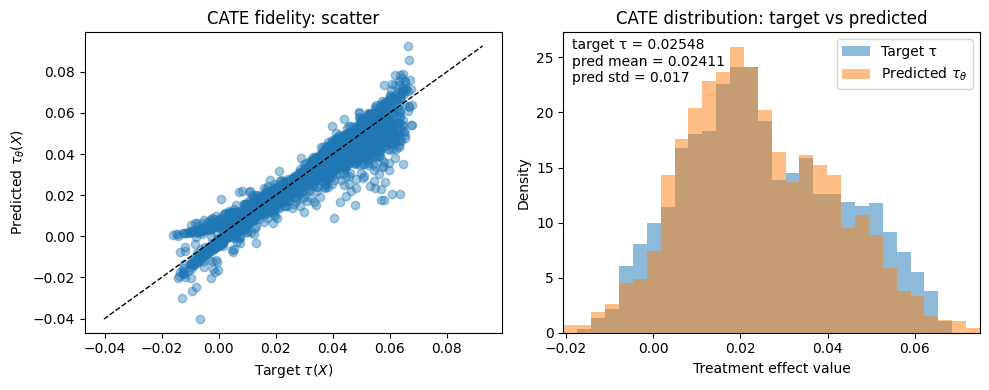

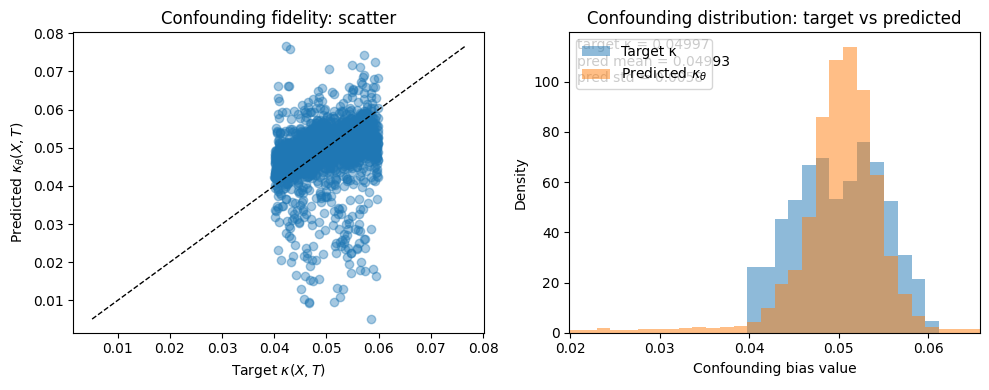

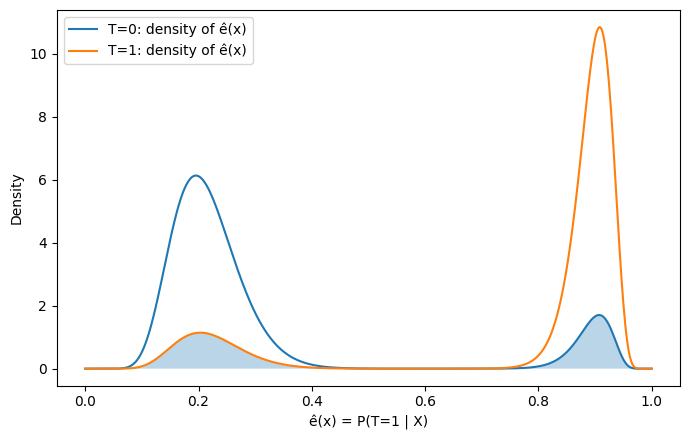

CausalEvalResults(mae_tau=0.004, corr_tau=0.957, ate_pred=0.024, ate_target=0.025, ate_abs_error=0.001, tau_wasserstein=0.002, mae_kappa=0.004, mae_kappa_t0=0.005, mae_kappa_t1=0.003, kappa_wasserstein=0.002, overlap_coeff=0.237, bw0=0.345, bw1=0.345)


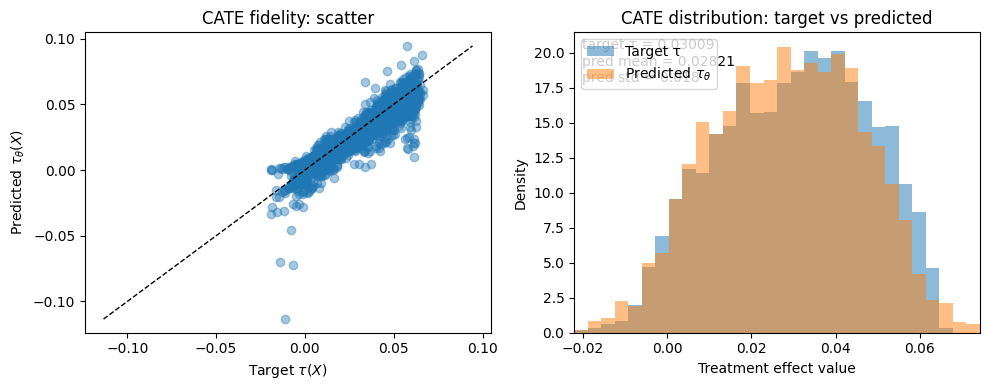

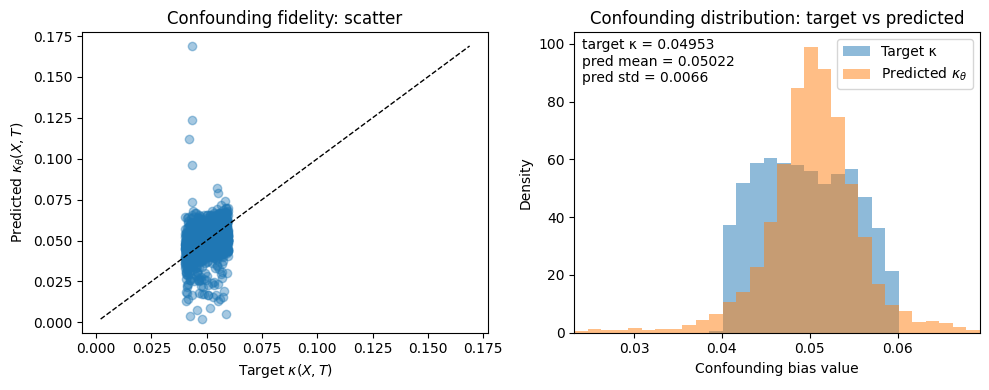

In [0]:
# generate new samples and return causal evaluation metrics
out3_bgmm = m3.causal_bgmm(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
)
out3_gauss = m3.causal_gauss(
    n_samples=mcrpc_data.shape[0],
    deterministic=False,
    return_probs=False,
    plot=True,
)

cm_metrics = out3_bgmm["causal_metrics"]
df_gen = out3_bgmm["df_gen"]
df_Y = out3_bgmm["df_Y"]
df_Ymean = out3_bgmm["df_Ymean"]
df_Ymean_prime = out3_bgmm["df_Ymean_prime"] 
stats = out3_bgmm["stats"]
print(cm_metrics)

In [0]:
overlap = out3_bgmm["overlap"]
print(overlap)
overlap2 = out3_gauss["overlap"]
print(overlap2)

{'dec/log_ratio_mean': -0.19, 'dec/log_ratio_std': 1.955, 'dec/target_mean': -0.199, 'dec/target_std': 1.99, 'dec/mse_to_target': 0.005, 'dec/fraction_within_tol': 0.997, 'ps/auc': 0.893, 'ps/hist_overlap_coeff': 0.237, 'ps/frac_common_support': 0.999, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 0.999}
{'dec/log_ratio_mean': -0.198, 'dec/log_ratio_std': 2.046, 'dec/target_mean': -0.161, 'dec/target_std': 1.994, 'dec/mse_to_target': 0.458, 'dec/fraction_within_tol': 0.93, 'ps/auc': 0.863, 'ps/hist_overlap_coeff': 0.298, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


In [0]:
schema = DataSchema(
    numeric = numerical_var,
    binary = binary_var,
    categorical = categorical_var
)
evaluator_bgmm = SynthEval(mcrpc_data, out3_bgmm["df_gen"], schema)
dist_bgmm3 = evaluator_bgmm.run_all(conditional_col = "exp")
evaluator_gauss = SynthEval(mcrpc_data, out3_gauss["df_gen"], schema)
dist_gauss3 = evaluator_gauss.run_all(conditional_col = "exp")

dist_all = {
    "BGMM": dist_bgmm3,
    "Gaussian": dist_gauss3
}
t_dist = build_table_distributional_fidelity(dist_all)
t_privacy = build_table_privacy(dist_all)

causal_all = {
    "BGMM": out3_bgmm,
    "Gaussian": out3_gauss
}
t_causal = build_table_causal_structure(causal_all)


print(t_causal)  # replaced Databricks display() with print()
print(t_dist)  # replaced Databricks display() with print()
print(t_privacy)  # replaced Databricks display() with print()

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Category,Metric,Direction,BGMM,Gaussian
Treatment Effect,CATE/ITE MAE,↓ better,0.004,0.004
Treatment Effect,CATE Correlation,↑ better,0.957,0.939
Treatment Effect,ATE Error,↓ better,0.001,0.002
Treatment Effect,TE Distribution Distance (W1),↓ better,0.002,0.002
Confounding,Confounding MAE,↓ better,0.004,0.005
Confounding,Group-wise MAE (T=0),↓ better,0.005,0.005
Confounding,Group-wise MAE (T=1),↓ better,0.003,0.004
Confounding,Confounding Dist. (W1),↓ better,0.002,0.002
Overlap (decoder),Δ vs target MSE,↓ better,0.005,0.458
Overlap (decoder),Fraction within tolerance,↑ better,0.997,0.93


Category,Metric,Direction,BGMM,Gaussian
Marginal (cont.),Normalized Wasserstein (mean),↓ better,0.075,0.702
Marginal (cont.),KSComplement (mean),↑ better,0.953,0.707
Marginal (disc.),TVComplement (mean),↑ better,0.961,0.899
Pairwise (cont–cont.),CorrelationSimilarity,↑ better,0.985,0.879
Pairwise (all vars),SU similarity (mean),↑ better,0.992,0.989
Pairwise (disc–disc.),ContingencySimilarity (mean),↑ better,0.927,0.841
Conditional (all except C),Weighted MMD$^2$,↓ better,0.026,0.028
Conditional (all except C),Normalized $MMD$^2$ ratio vs real,↓ better; 1 = real-data baseline,9.561,10.279
Joint (all vars),Normalized Energy Distance,↓ better,0.011,0.083
Joint (all vars),C2ST (AUC complement),↑ better.,0.639,0.325


Category,Metric,Direction,BGMM,Gaussian
DCR,Protection Fraction,↑ better,0.719,0.844
DCR,Distance Ratio (mean),↑ better,3.485,3.497
DCR,Distance Ratio (p5),↑ better,0.454,0.81
DCR,Distance Ratio (p50),↑ better,1.169,1.341
DCR,Distance Ratio (p95),↑ better,6.0,11.881
DCR,Standardized Distance Ratio,↑ better,0.302,0.56


Overlap metrics: {'dec/log_ratio_mean': -0.17, 'dec/log_ratio_std': 1.956, 'dec/target_mean': -0.179, 'dec/target_std': 1.992, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.997, 'ps/auc': 0.89, 'ps/hist_overlap_coeff': 0.247, 'ps/frac_common_support': 0.998, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 0.997}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


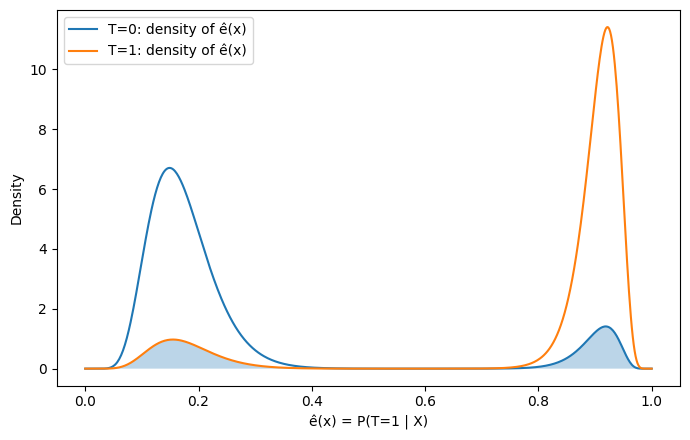

Overlap metrics: {'dec/log_ratio_mean': -0.131, 'dec/log_ratio_std': 2.028, 'dec/target_mean': -0.093, 'dec/target_std': 1.998, 'dec/mse_to_target': 0.356, 'dec/fraction_within_tol': 0.936, 'ps/auc': 0.854, 'ps/hist_overlap_coeff': 0.324, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


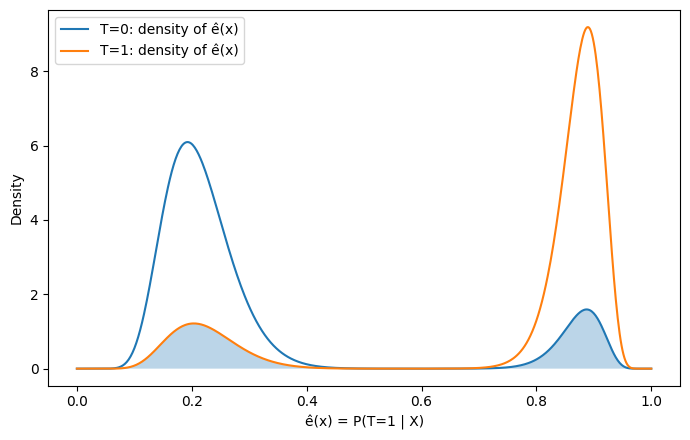

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.198, 'dec/log_ratio_std': 1.954, 'dec/target_mean': -0.206, 'dec/target_std': 1.989, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.997, 'ps/auc': 0.882, 'ps/hist_overlap_coeff': 0.254, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 0.999, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


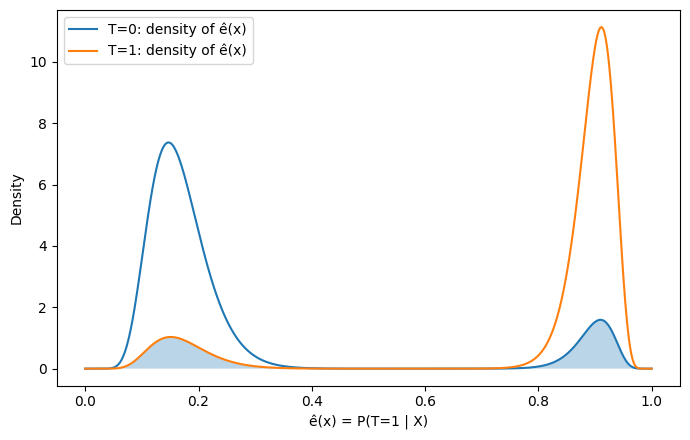

Overlap metrics: {'dec/log_ratio_mean': -0.153, 'dec/log_ratio_std': 2.057, 'dec/target_mean': -0.123, 'dec/target_std': 1.996, 'dec/mse_to_target': 0.469, 'dec/fraction_within_tol': 0.932, 'ps/auc': 0.856, 'ps/hist_overlap_coeff': 0.316, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


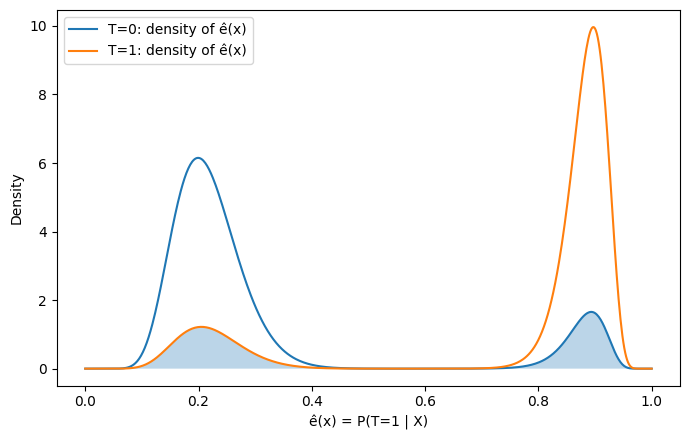

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.247, 'dec/log_ratio_std': 1.95, 'dec/target_mean': -0.257, 'dec/target_std': 1.983, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.995, 'ps/auc': 0.885, 'ps/hist_overlap_coeff': 0.252, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


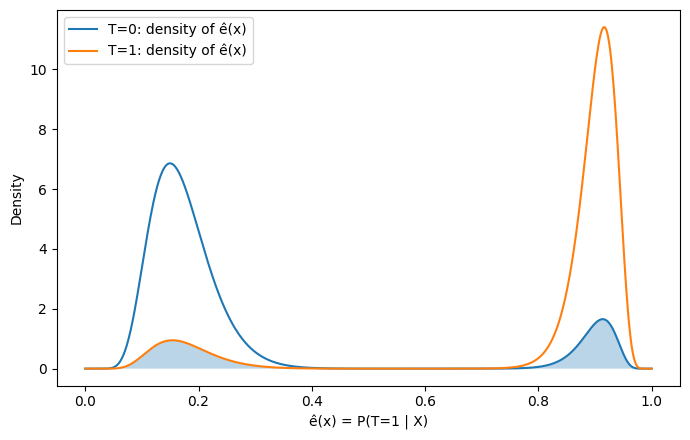

Overlap metrics: {'dec/log_ratio_mean': -0.136, 'dec/log_ratio_std': 2.003, 'dec/target_mean': -0.108, 'dec/target_std': 1.997, 'dec/mse_to_target': 0.217, 'dec/fraction_within_tol': 0.939, 'ps/auc': 0.857, 'ps/hist_overlap_coeff': 0.308, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


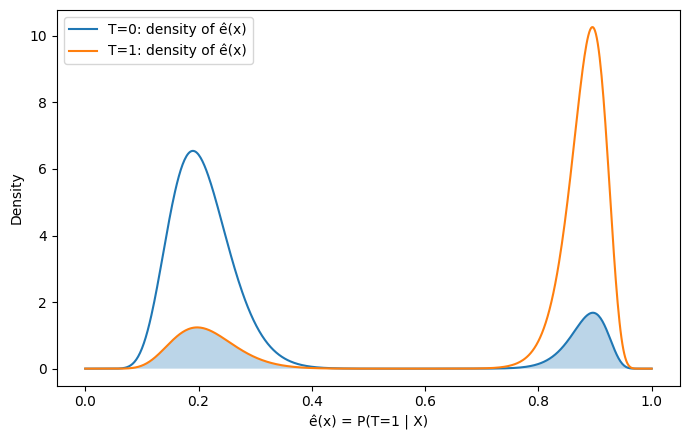

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.14, 'dec/log_ratio_std': 1.96, 'dec/target_mean': -0.148, 'dec/target_std': 1.994, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.995, 'ps/auc': 0.892, 'ps/hist_overlap_coeff': 0.243, 'ps/frac_common_support': 0.997, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 0.994}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


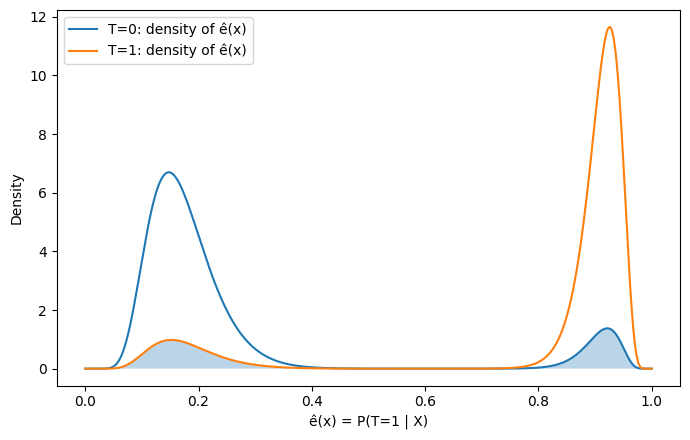

Overlap metrics: {'dec/log_ratio_mean': -0.184, 'dec/log_ratio_std': 2.002, 'dec/target_mean': -0.153, 'dec/target_std': 1.994, 'dec/mse_to_target': 0.291, 'dec/fraction_within_tol': 0.928, 'ps/auc': 0.865, 'ps/hist_overlap_coeff': 0.307, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


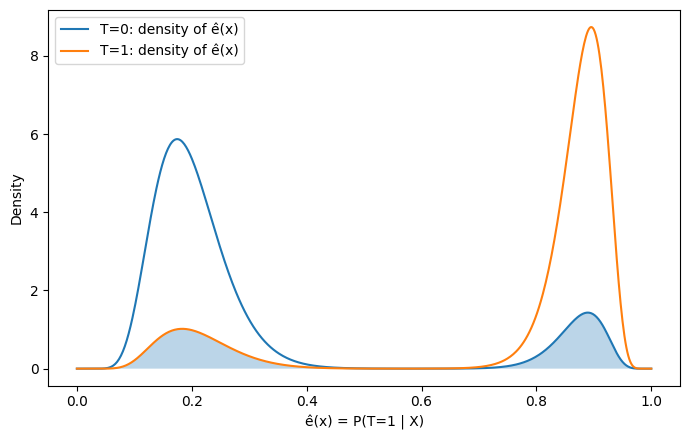

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.191, 'dec/log_ratio_std': 1.955, 'dec/target_mean': -0.199, 'dec/target_std': 1.99, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.996, 'ps/auc': 0.887, 'ps/hist_overlap_coeff': 0.246, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


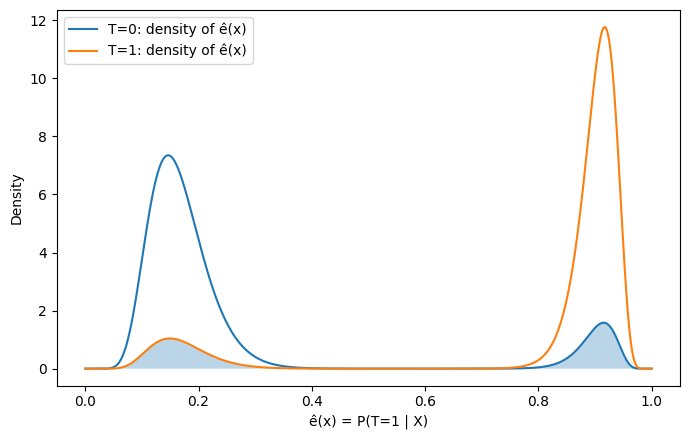

Overlap metrics: {'dec/log_ratio_mean': -0.15, 'dec/log_ratio_std': 2.03, 'dec/target_mean': -0.117, 'dec/target_std': 1.997, 'dec/mse_to_target': 0.3, 'dec/fraction_within_tol': 0.937, 'ps/auc': 0.857, 'ps/hist_overlap_coeff': 0.312, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


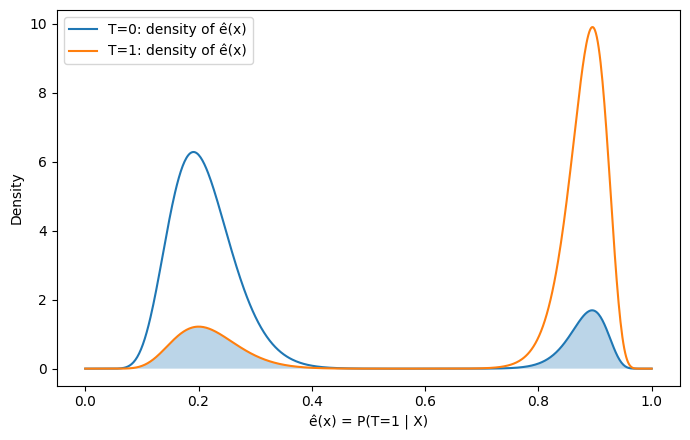

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.191, 'dec/log_ratio_std': 1.956, 'dec/target_mean': -0.2, 'dec/target_std': 1.99, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.997, 'ps/auc': 0.898, 'ps/hist_overlap_coeff': 0.225, 'ps/frac_common_support': 0.997, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 0.995}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


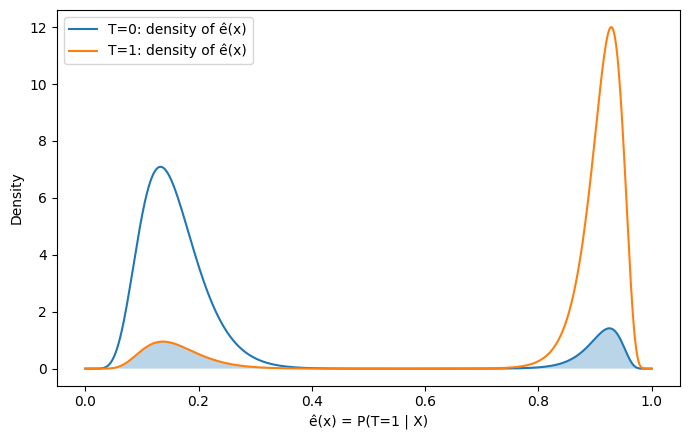

Overlap metrics: {'dec/log_ratio_mean': -0.204, 'dec/log_ratio_std': 2.021, 'dec/target_mean': -0.17, 'dec/target_std': 1.993, 'dec/mse_to_target': 0.297, 'dec/fraction_within_tol': 0.934, 'ps/auc': 0.852, 'ps/hist_overlap_coeff': 0.316, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


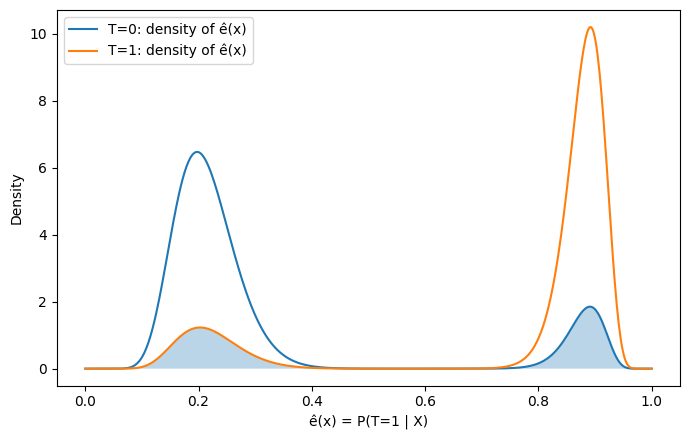

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.149, 'dec/log_ratio_std': 1.96, 'dec/target_mean': -0.157, 'dec/target_std': 1.994, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.996, 'ps/auc': 0.897, 'ps/hist_overlap_coeff': 0.228, 'ps/frac_common_support': 0.994, 'ps/frac_common_support_t0': 0.999, 'ps/frac_common_support_t1': 0.991}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


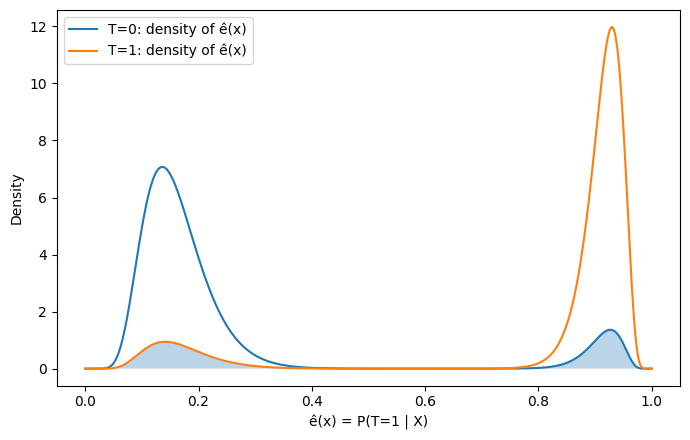

Overlap metrics: {'dec/log_ratio_mean': -0.167, 'dec/log_ratio_std': 2.003, 'dec/target_mean': -0.149, 'dec/target_std': 1.994, 'dec/mse_to_target': 0.196, 'dec/fraction_within_tol': 0.933, 'ps/auc': 0.867, 'ps/hist_overlap_coeff': 0.295, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


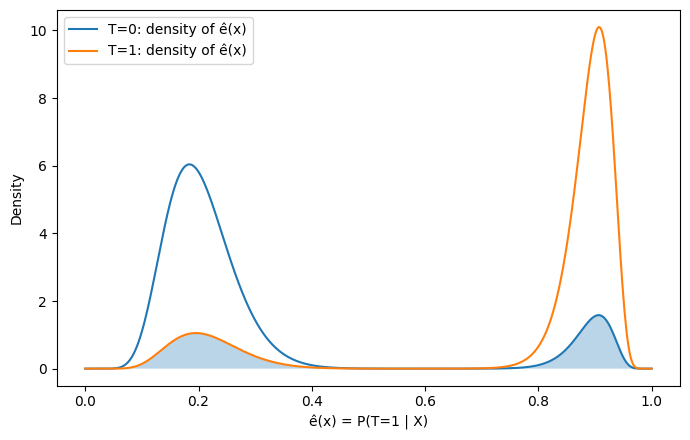

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.178, 'dec/log_ratio_std': 1.957, 'dec/target_mean': -0.186, 'dec/target_std': 1.991, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.996, 'ps/auc': 0.88, 'ps/hist_overlap_coeff': 0.253, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


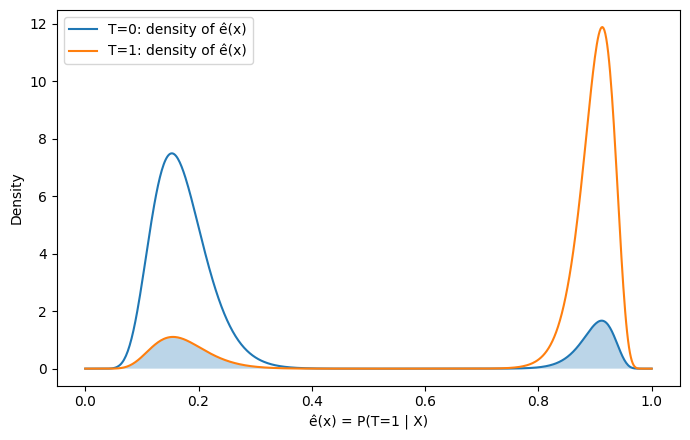

Overlap metrics: {'dec/log_ratio_mean': -0.154, 'dec/log_ratio_std': 1.984, 'dec/target_mean': -0.136, 'dec/target_std': 1.995, 'dec/mse_to_target': 0.162, 'dec/fraction_within_tol': 0.929, 'ps/auc': 0.861, 'ps/hist_overlap_coeff': 0.303, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


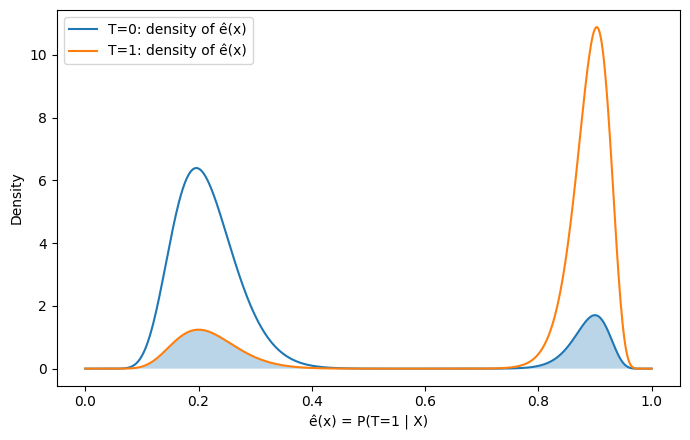

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.164, 'dec/log_ratio_std': 1.957, 'dec/target_mean': -0.174, 'dec/target_std': 1.992, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.995, 'ps/auc': 0.897, 'ps/hist_overlap_coeff': 0.225, 'ps/frac_common_support': 0.993, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 0.988}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


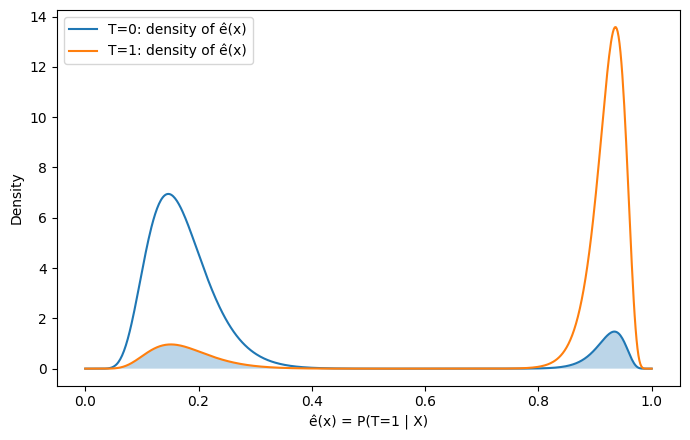

Overlap metrics: {'dec/log_ratio_mean': -0.148, 'dec/log_ratio_std': 2.042, 'dec/target_mean': -0.11, 'dec/target_std': 1.997, 'dec/mse_to_target': 0.355, 'dec/fraction_within_tol': 0.937, 'ps/auc': 0.857, 'ps/hist_overlap_coeff': 0.309, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


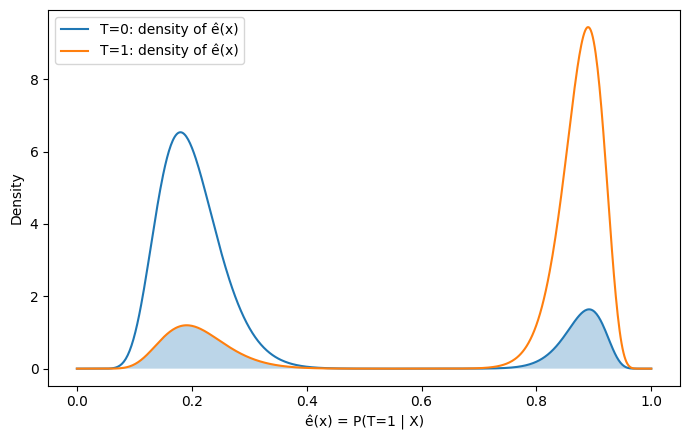

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Overlap metrics: {'dec/log_ratio_mean': -0.196, 'dec/log_ratio_std': 1.954, 'dec/target_mean': -0.206, 'dec/target_std': 1.989, 'dec/mse_to_target': 0.004, 'dec/fraction_within_tol': 0.995, 'ps/auc': 0.887, 'ps/hist_overlap_coeff': 0.254, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}
checking
X_np: (4098, 18)
T_np: (4098,)
tau_pred: (4098,)
kappa_pred: (4098,)
tau_target: (4098,)
kappa_target: (4098,)


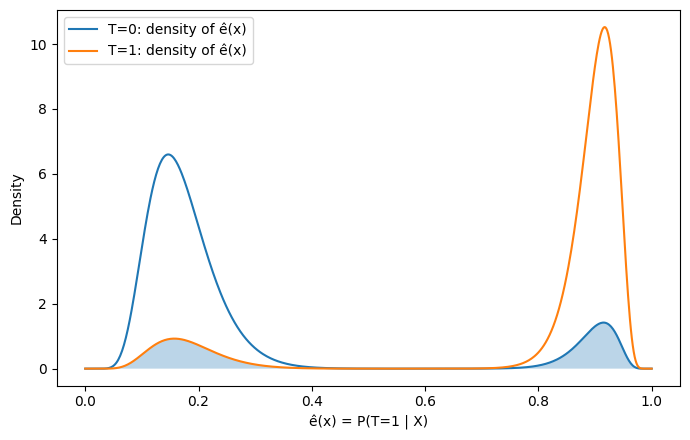

Overlap metrics: {'dec/log_ratio_mean': -0.148, 'dec/log_ratio_std': 2.039, 'dec/target_mean': -0.11, 'dec/target_std': 1.997, 'dec/mse_to_target': 0.356, 'dec/fraction_within_tol': 0.936, 'ps/auc': 0.864, 'ps/hist_overlap_coeff': 0.3, 'ps/frac_common_support': 1.0, 'ps/frac_common_support_t0': 1.0, 'ps/frac_common_support_t1': 1.0}


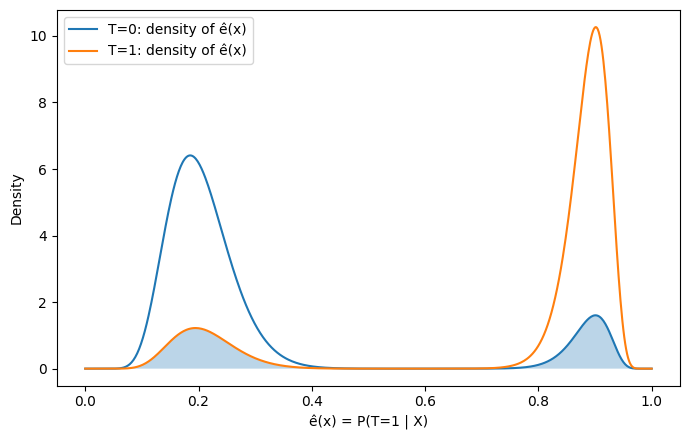

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-bf926c067326/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:296: FutureWarning:

The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.

/local_disk0/.ephemeral_nfs/envs/pythonEnv-c47cefcc-b0d8-4fe0-915b-b

Category,Metric,Direction,BGMM,Gaussian
Treatment Effect,CATE/ITE MAE,↓ better,0.004 (0.000),0.004 (0.000)
Treatment Effect,CATE Correlation,↑ better,0.956 (0.003),0.931 (0.005)
Treatment Effect,ATE Error,↓ better,0.001 (0.000),0.002 (0.000)
Treatment Effect,TE Distribution Distance (W1),↓ better,0.002 (0.000),0.002 (0.000)
Confounding,Confounding MAE,↓ better,0.004 (0.000),0.005 (0.000)
Confounding,Group-wise MAE (T=0),↓ better,0.005 (0.000),0.005 (0.000)
Confounding,Group-wise MAE (T=1),↓ better,0.003 (0.000),0.004 (0.000)
Confounding,Confounding Dist. (W1),↓ better,0.002 (0.000),0.002 (0.000)
Overlap (decoder),Δ vs target MSE,↓ better,0.004 (0.000),0.300 (0.091)
Overlap (decoder),Fraction within tolerance,↑ better,0.996 (0.001),0.934 (0.004)


Category,Metric,Direction,BGMM,Gaussian
Marginal (cont.),Normalized Wasserstein (mean),↓ better,0.075 (0.001),0.679 (0.008)
Marginal (cont.),KSComplement (mean),↑ better,0.954 (0.001),0.720 (0.005)
Marginal (disc.),TVComplement (mean),↑ better,0.961 (0.001),0.898 (0.002)
Pairwise (cont–cont.),CorrelationSimilarity,↑ better,0.984 (0.002),0.883 (0.009)
Pairwise (all vars),SU similarity (mean),↑ better,0.991 (0.002),0.990 (0.000)
Pairwise (disc–disc.),ContingencySimilarity (mean),↑ better,0.928 (0.001),0.841 (0.003)
Conditional (all except C),Weighted MMD$^2$,↓ better,0.023 (0.002),0.029 (0.002)
Conditional (all except C),Normalized $MMD$^2$ ratio vs real,↓ better; 1 = real-data baseline,8.563 (0.604),10.863 (0.724)
Joint (all vars),Normalized Energy Distance,↓ better,0.011 (0.000),0.080 (0.002)
Joint (all vars),C2ST (AUC complement),↑ better.,0.625 (0.008),0.333 (0.010)


Category,Metric,Direction,BGMM,Gaussian
DCR,Protection Fraction,↑ better,0.720 (0.006),0.839 (0.004)
DCR,Distance Ratio (mean),↑ better,3.298 (0.245),4.287 (0.089)
DCR,Distance Ratio (p5),↑ better,0.396 (0.030),0.788 (0.014)
DCR,Distance Ratio (p50),↑ better,1.169 (0.007),1.337 (0.009)
DCR,Distance Ratio (p95),↑ better,6.046 (0.055),11.740 (0.493)
DCR,Standardized Distance Ratio,↑ better,0.297 (0.003),0.559 (0.005)


In [0]:
# -----------------------------------------------------------------------------------------------------------------------------
# Produce tables of Mean (sd) across n generated datasets for the three tables distribution, privacy, and causal structure
# -----------------------------------------------------------------------------------------------------------------------------
schema = DataSchema(numeric=numerical_var, binary=binary_var, categorical=categorical_var)

t_causal_m3, t_dist_m3, t_privacy_m3= eval_tables_mean(
    model=m3,
    real_df=mcrpc_data,
    schema=schema,
    R=10,
    conditional_col="exp",
    plot_each_run=False,
)

print(t_causal_m3)  # replaced Databricks display() with print()
print(t_dist_m3)  # replaced Databricks display() with print()
print(t_privacy_m3)  # replaced Databricks display() with print()

# Optional: save to Excel
with pd.ExcelWriter(output_result + "m3_tables_mean.xlsx", engine="openpyxl") as w:
    t_dist_m3.to_excel(w, sheet_name="DistributionalFidelity", index=False)
    t_privacy_m3.to_excel(w, sheet_name="Privacy", index=False)
    t_causal_m3.to_excel(w, sheet_name="CausalStructure", index=False)

In [0]:
# get the code to use in overleaf
print(t_causal_m3.to_latex(index=False, escape=False, float_format="%.3f"))
print(t_dist_m3.to_latex(index=False, escape=False, float_format="%.3f"))
print(t_privacy_m3.to_latex(index=False, escape=False, float_format="%.3f"))

\begin{tabular}{lllll}
\toprule
            Category &                        Metric &                                Direction &          BGMM &      Gaussian \\
\midrule
    Treatment Effect &                  CATE/ITE MAE &                                 ↓ better & 0.004 (0.000) & 0.004 (0.000) \\
    Treatment Effect &              CATE Correlation &                                 ↑ better & 0.956 (0.003) & 0.931 (0.005) \\
    Treatment Effect &                     ATE Error &                                 ↓ better & 0.001 (0.000) & 0.002 (0.000) \\
    Treatment Effect & TE Distribution Distance (W1) &                                 ↓ better & 0.002 (0.000) & 0.002 (0.000) \\
         Confounding &               Confounding MAE &                                 ↓ better & 0.004 (0.000) & 0.005 (0.000) \\
         Confounding &          Group-wise MAE (T=0) &                                 ↓ better & 0.005 (0.000) & 0.005 (0.000) \\
         Confounding &          Group-wise

/root/.ipykernel/13289/command-7424738471719790-2039802791:2: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/root/.ipykernel/13289/command-7424738471719790-2039802791:3: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/root/.ipykernel/13289/command-7424738471719790-2039802791:4: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. 

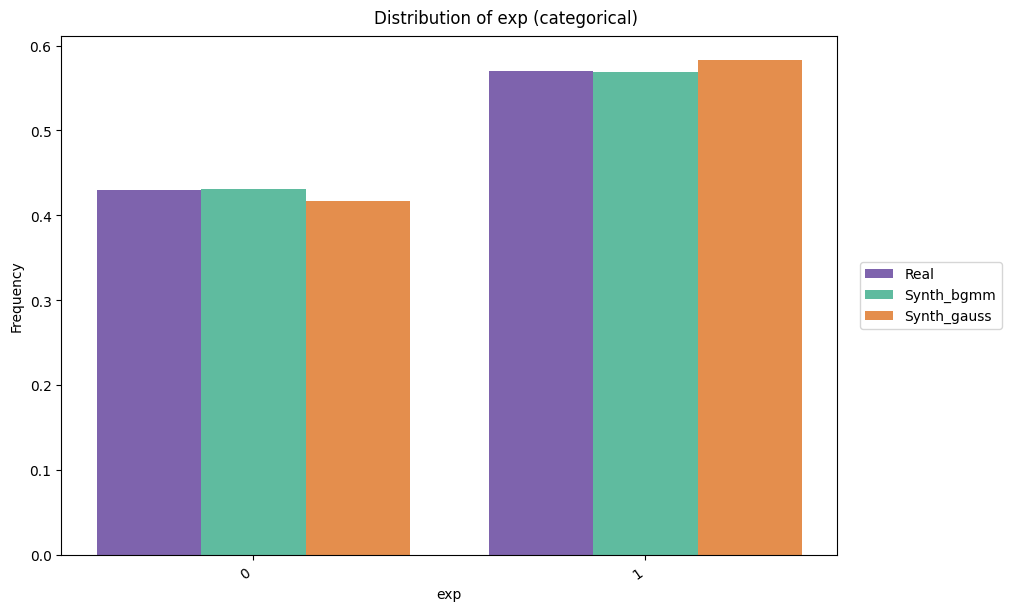

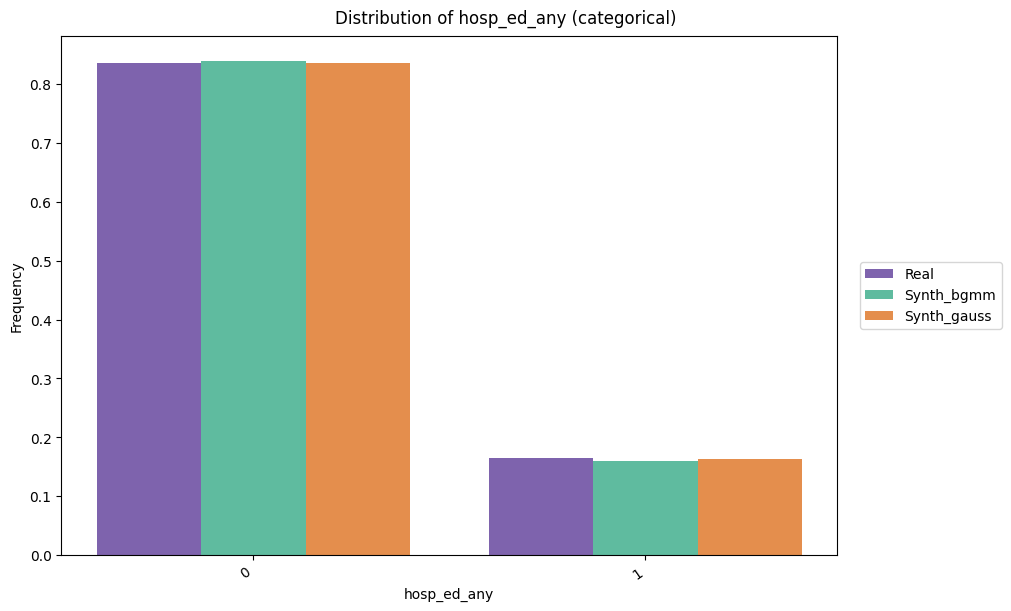

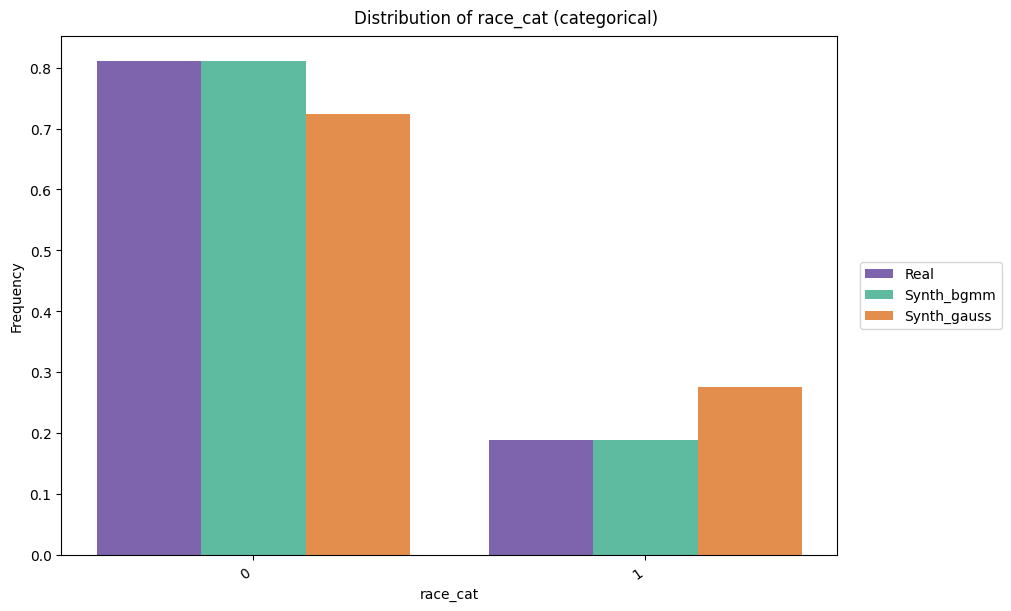

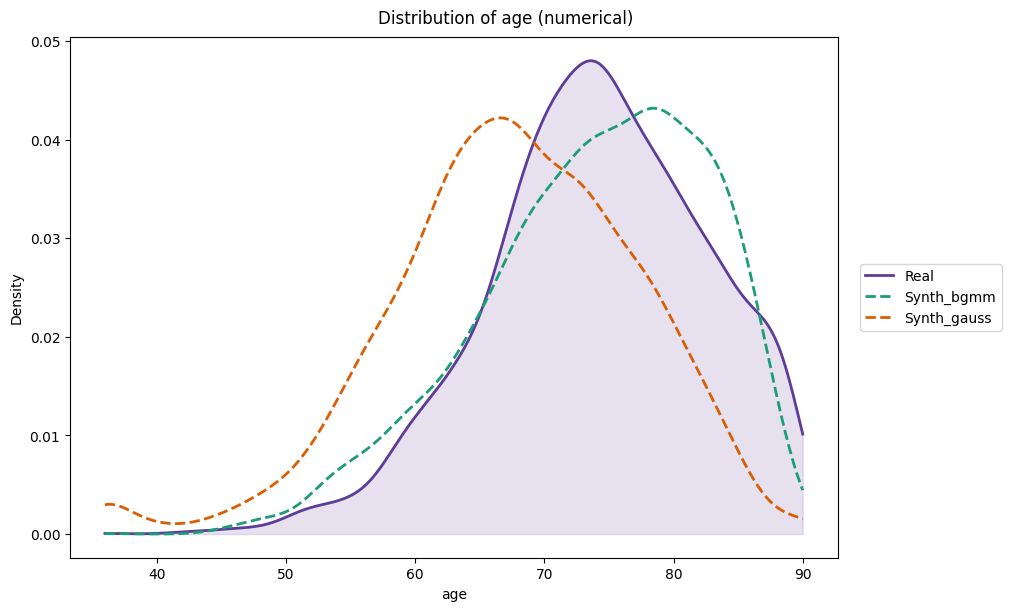

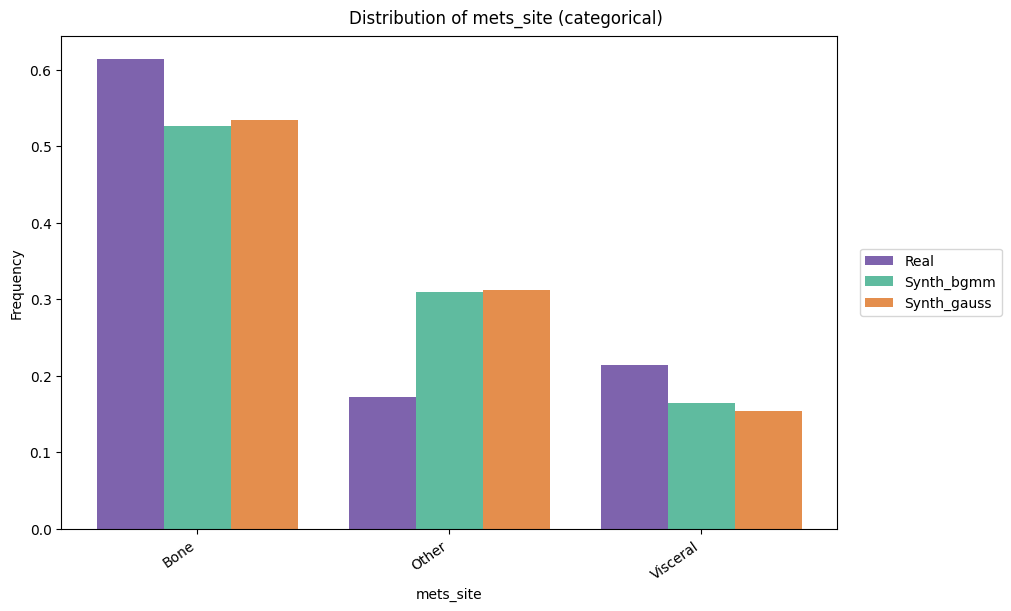

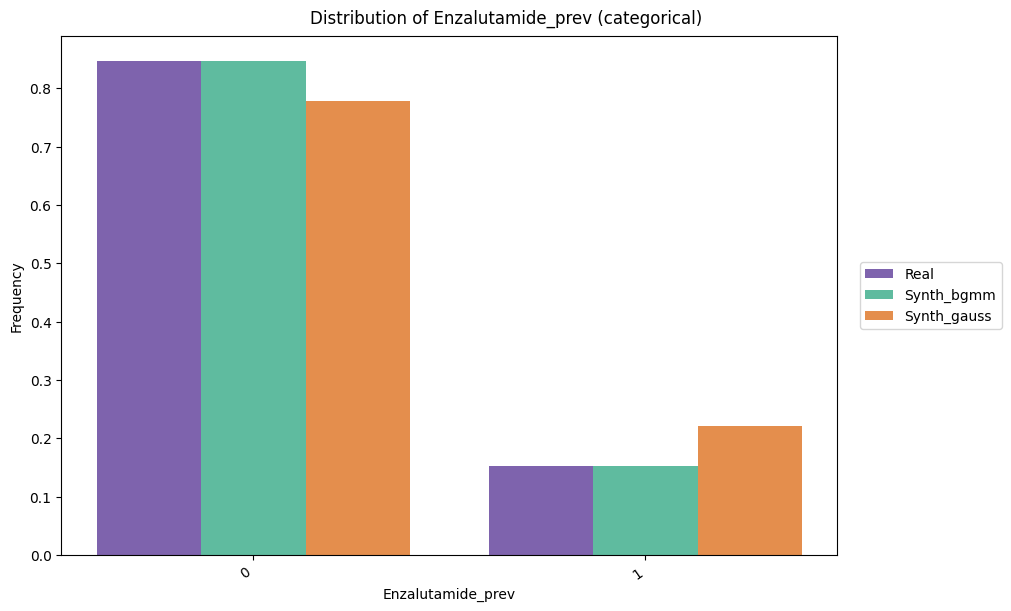

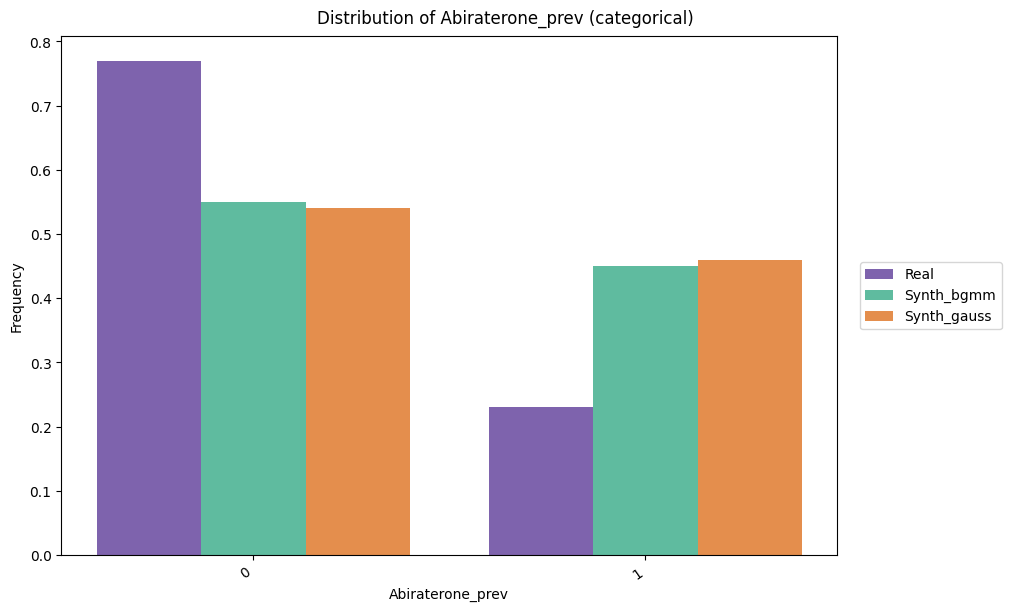

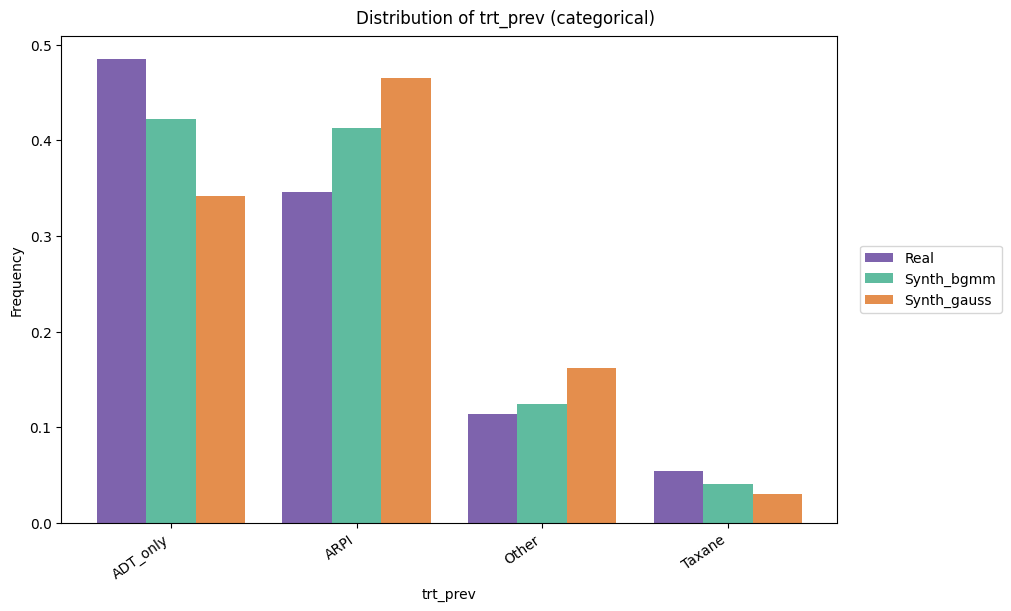

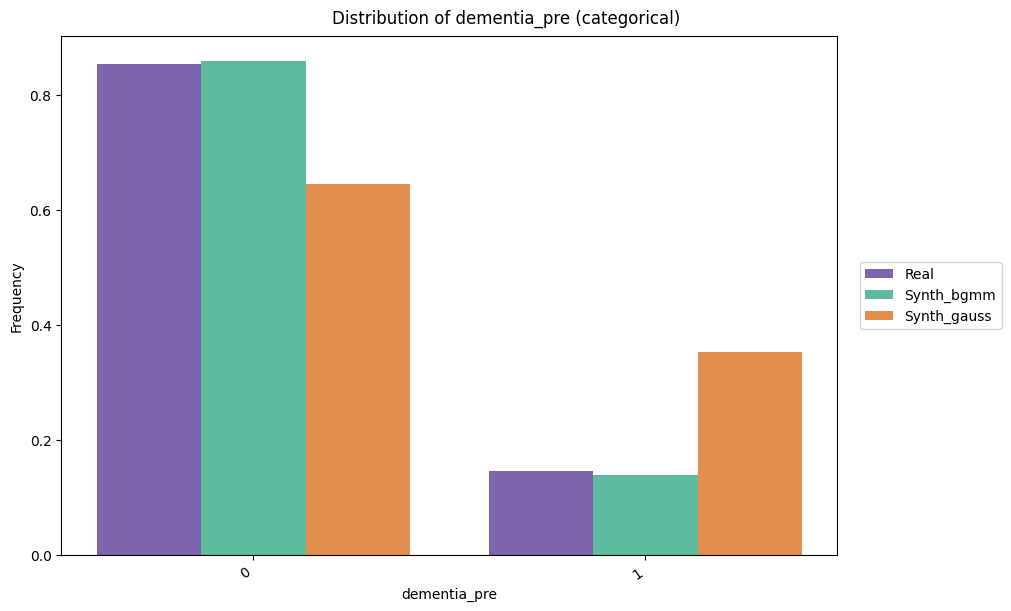

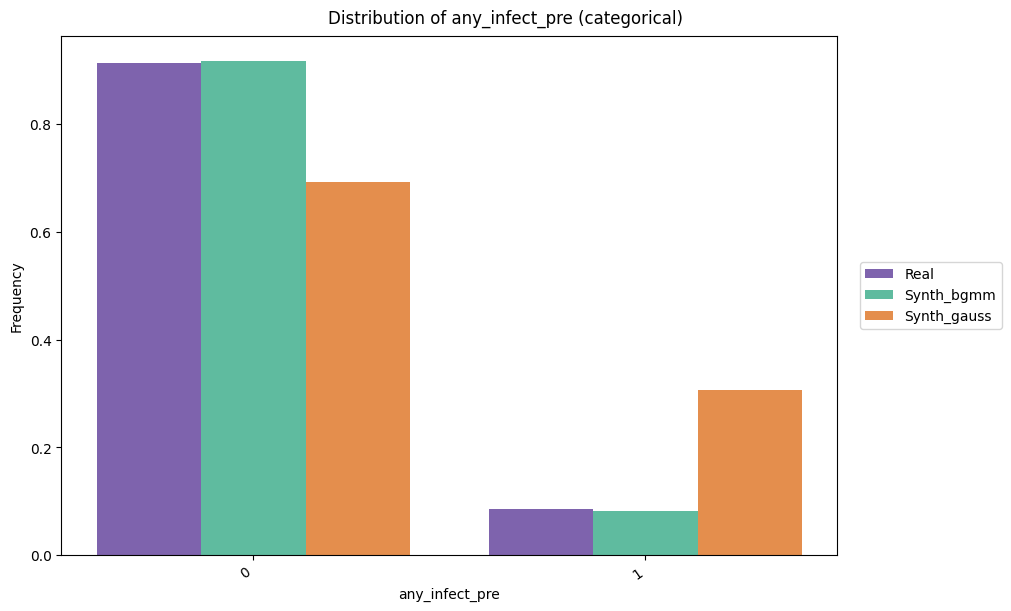

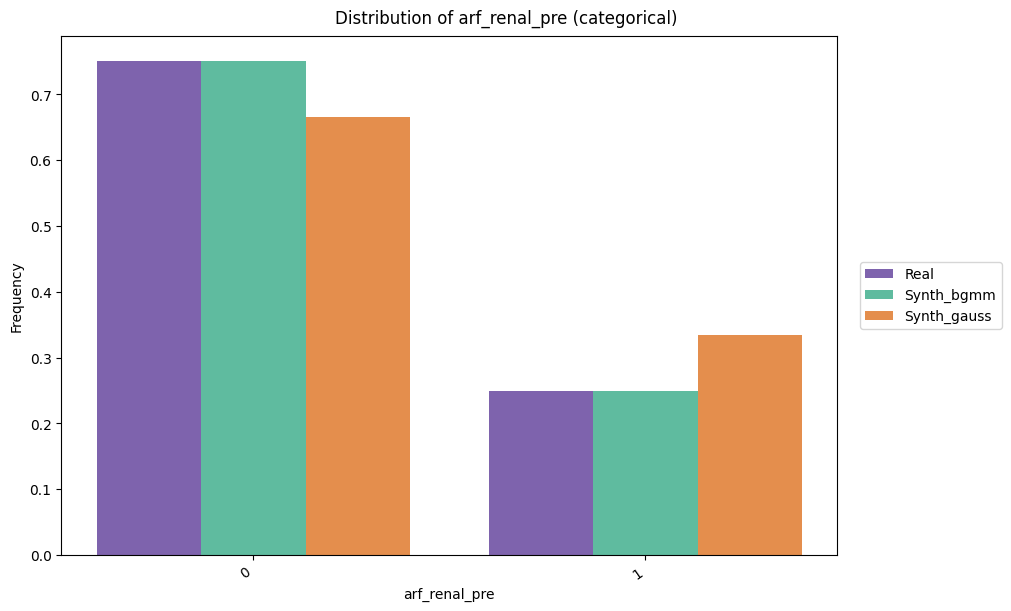

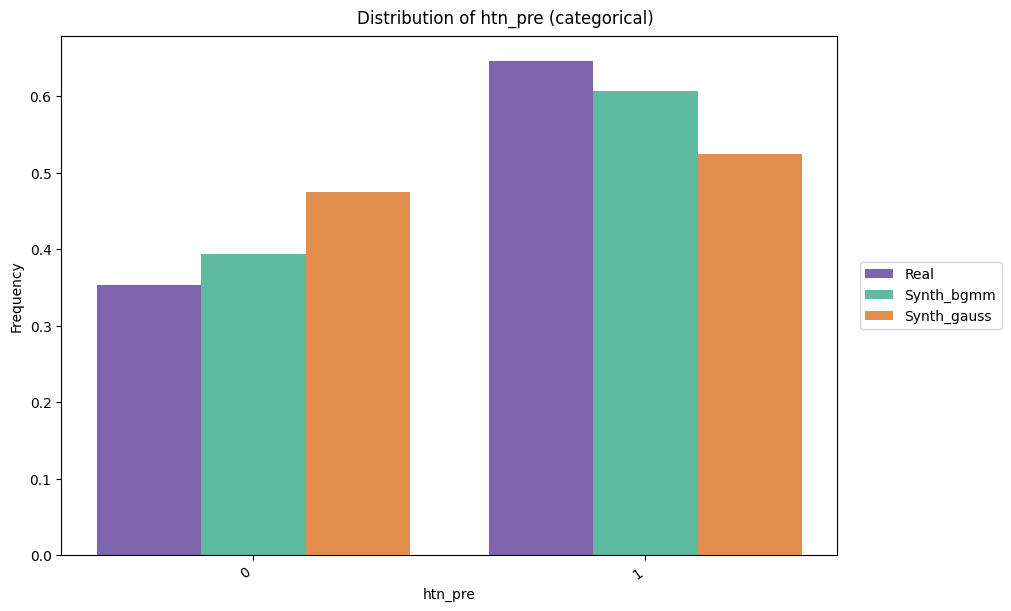

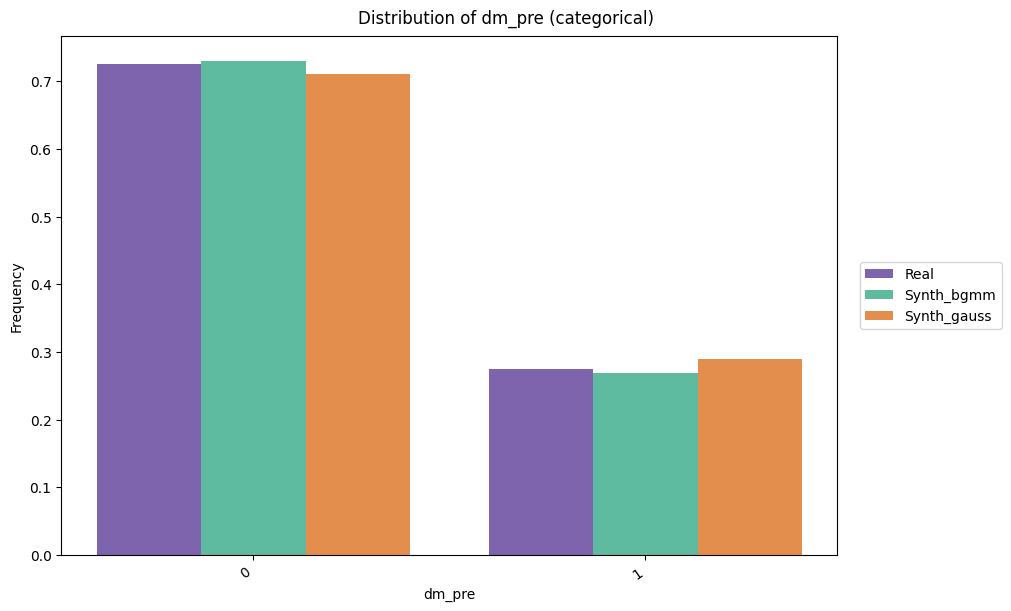

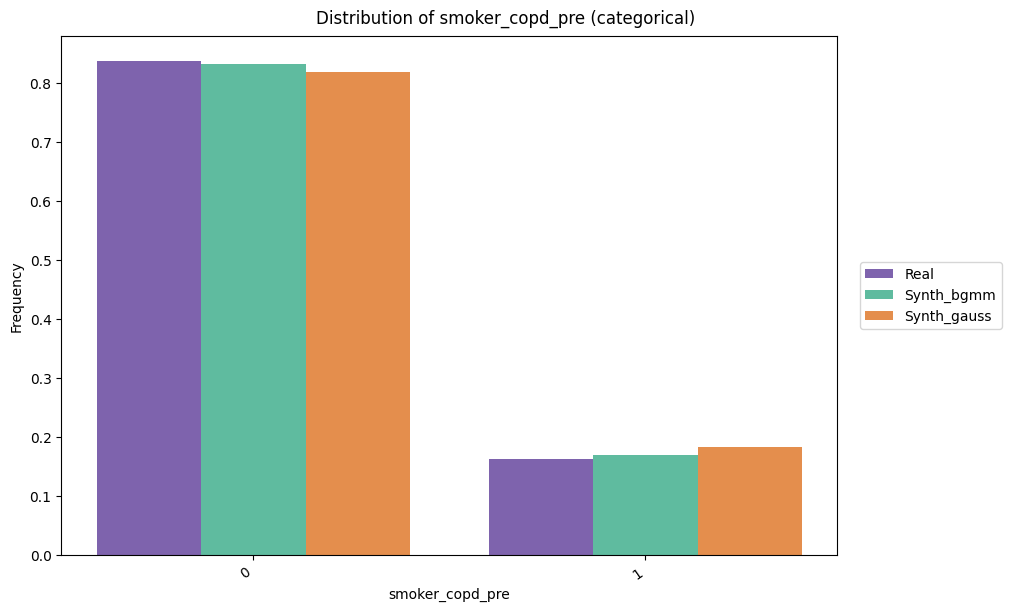

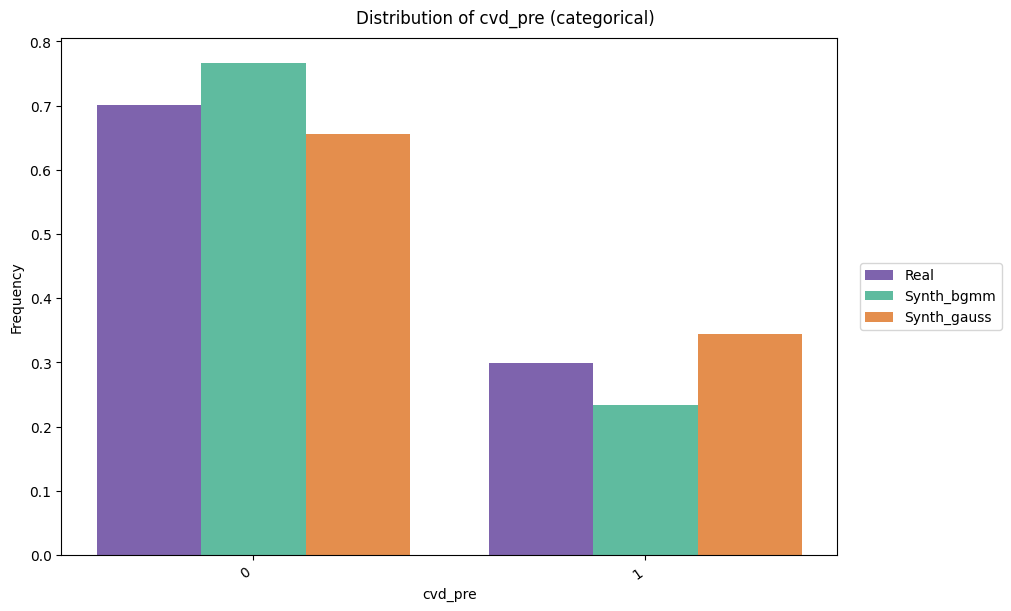

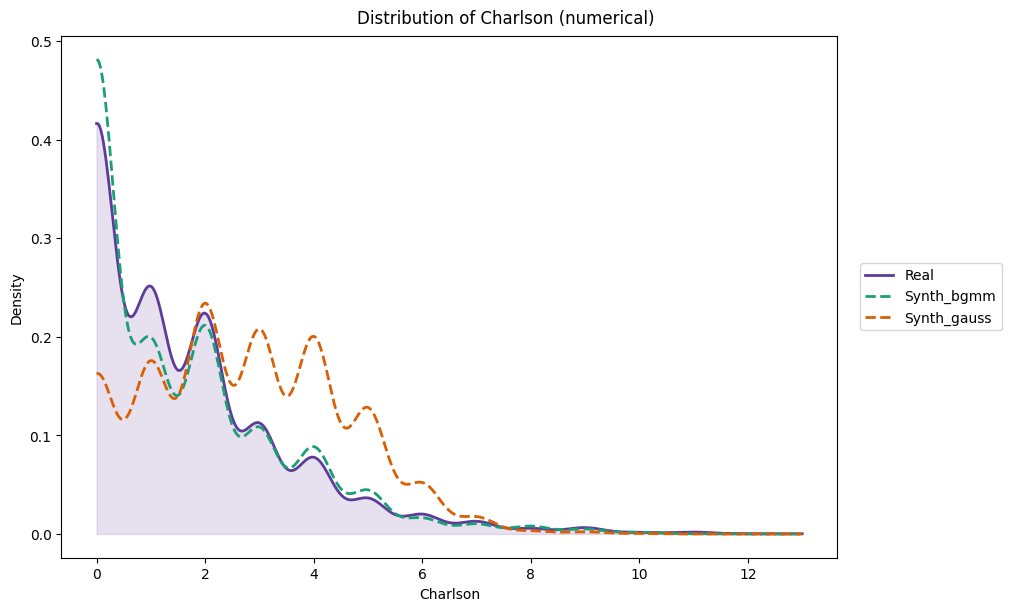

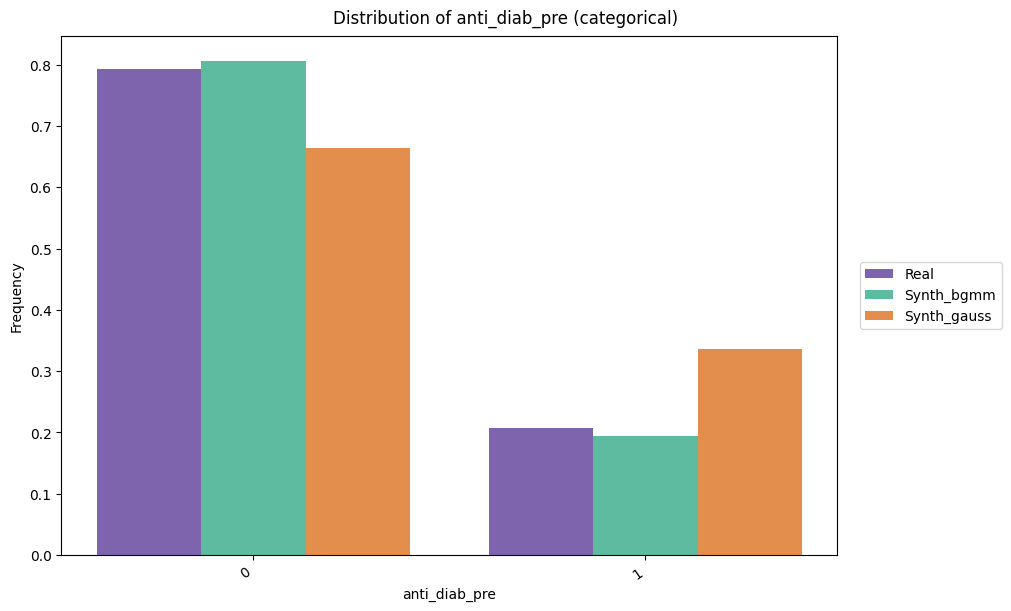

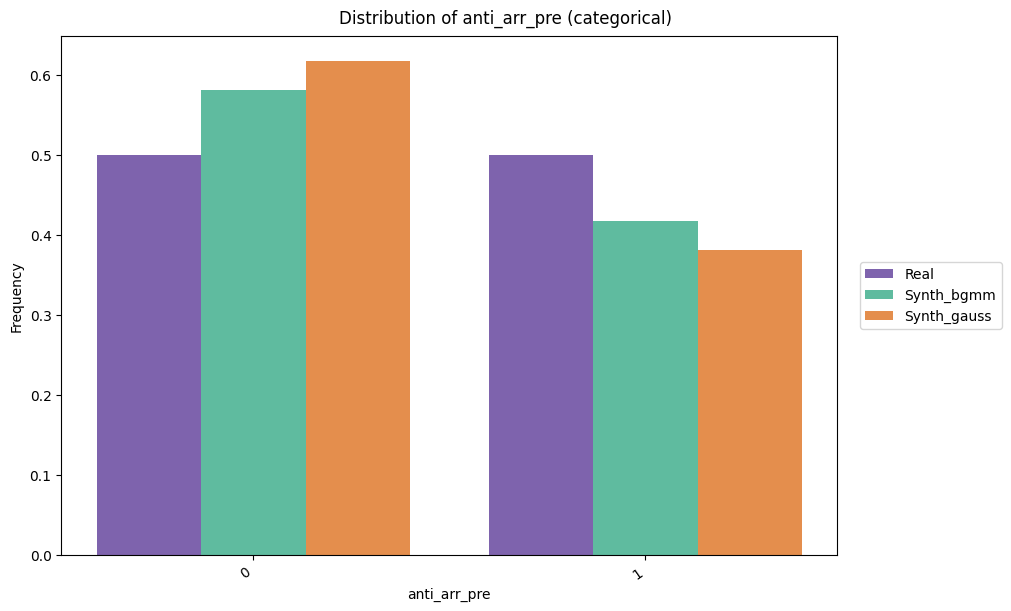

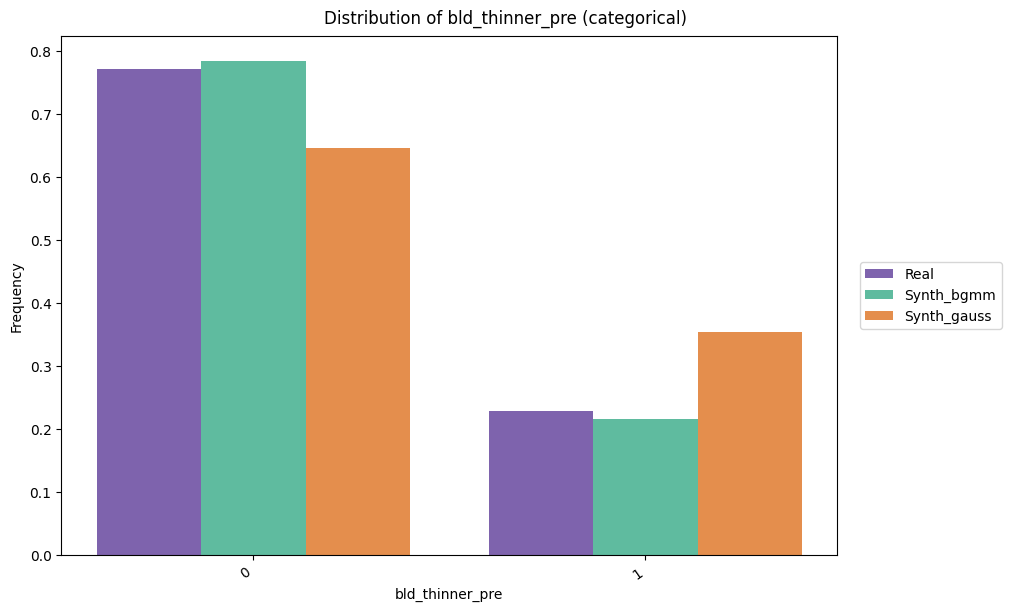

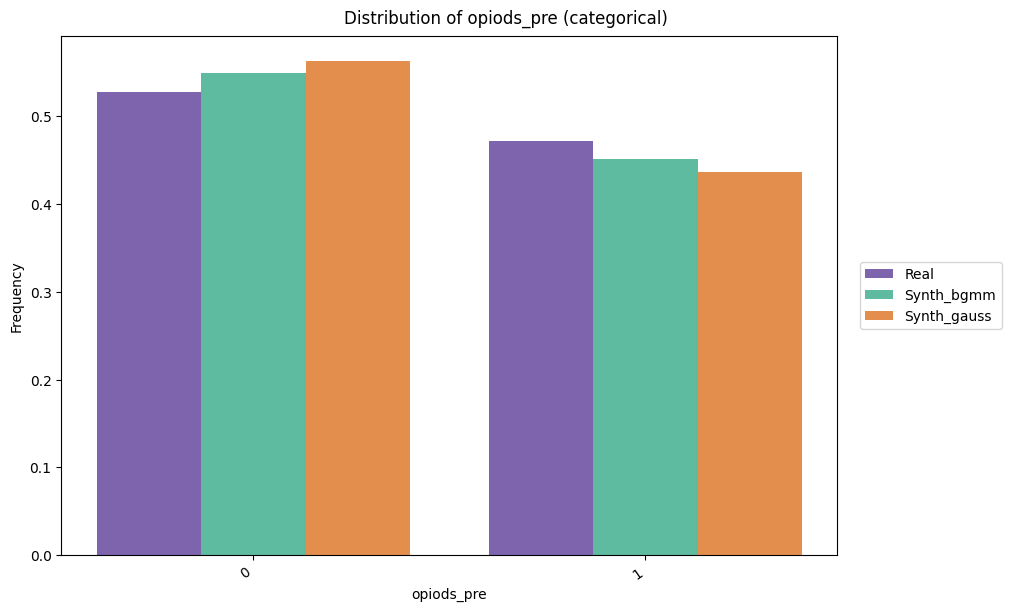

In [0]:
# check the distribution plots
synth_dict = {
    "Synth_bgmm": out3_bgmm["df_gen"],
    "Synth_gauss": out3_gauss["df_gen"]
}
# single column plots
for var in mcrpc_data.columns:
    fig = single_column_plot(
        real_data=mcrpc_data,
        synthetic_data=synth_dict,
        schema=schema,
        column_name=var,
        #main_title="Marginal distribution of age",
        x_label=var,
        y_label=None,
        fig_size=(10,6),
        legend_outside=True,
        #show_hist = True,
    )
    # save figure to pdf
    #fig.savefig(output_result + "column_" + var + ".pdf")
    fig.show()

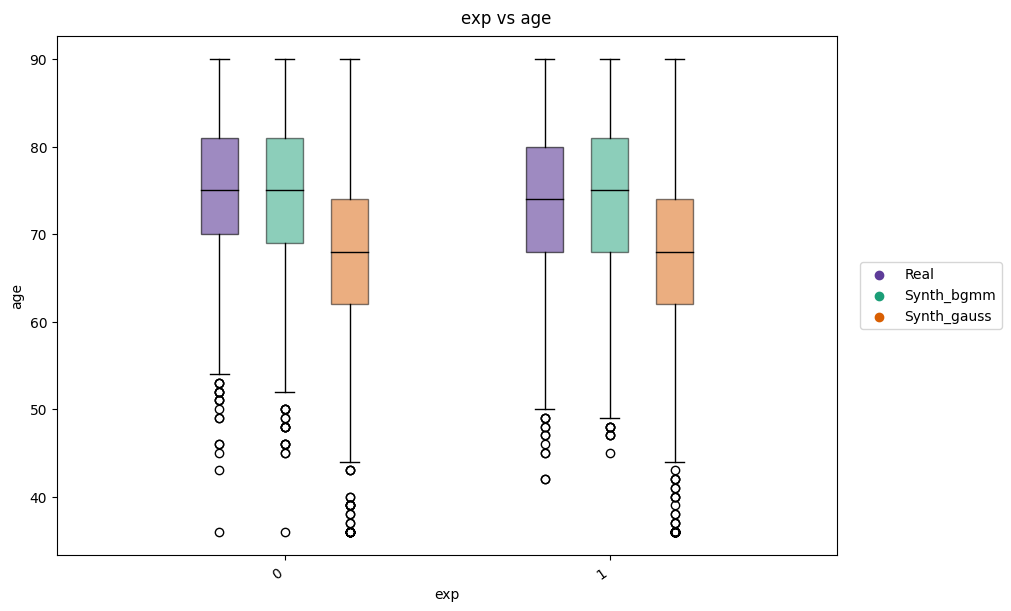

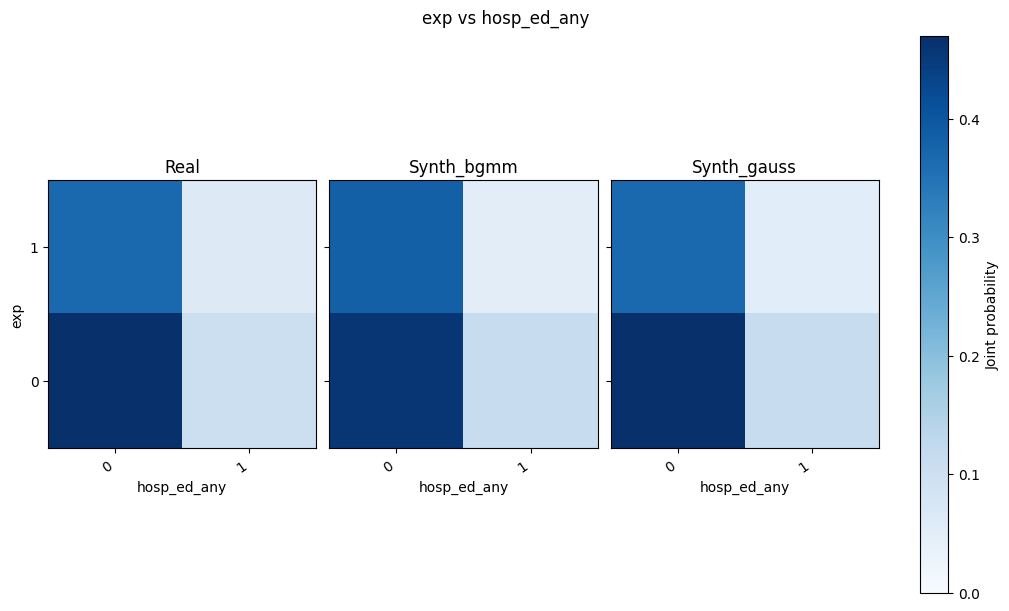

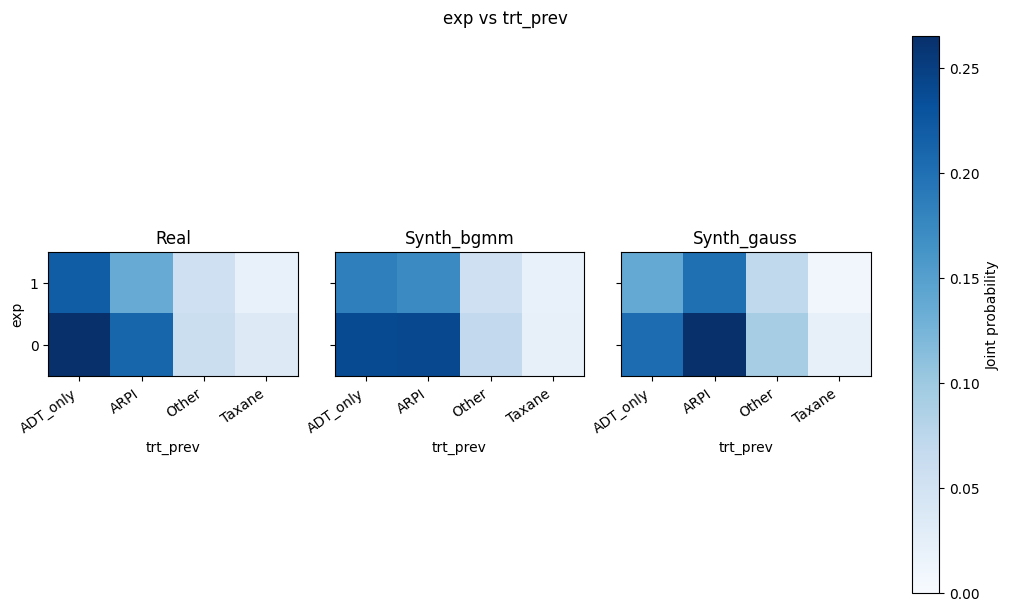

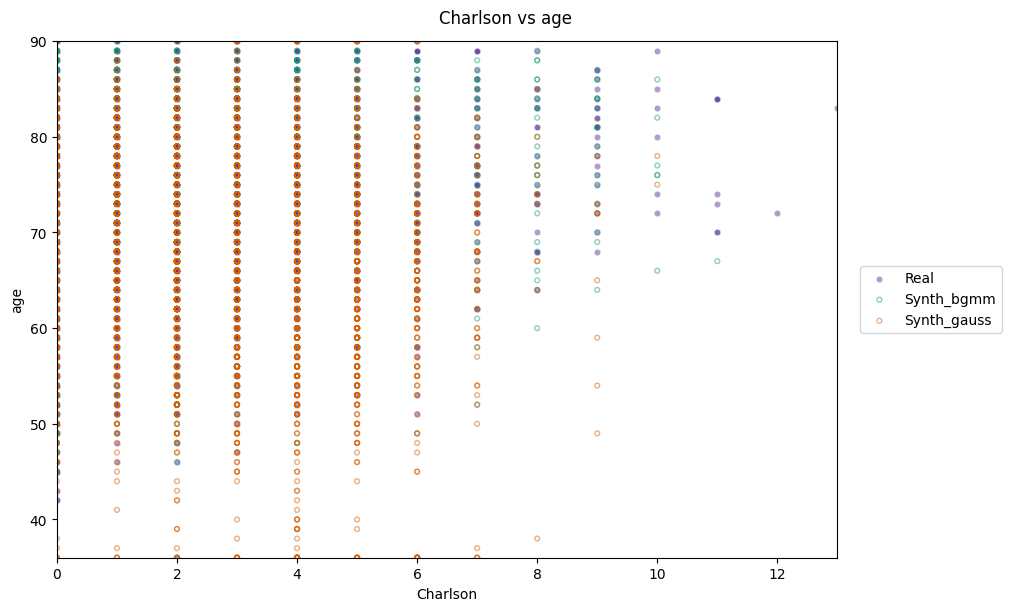

In [0]:
# pair column plots
column_names = [["exp", "age"], ["exp", "hosp_ed_any"], ["exp", "trt_prev"], ["Charlson", "age"]]
for pair in column_names:
    fig = pair_column_plot(
        real_data=mcrpc_data,
        synthetic_data=synth_dict,
        schema=schema,
        column_names=pair,
        #main_title="Marginal distribution of age",
        x_label=None,
        y_label=None,
        fig_size=(10,6),
        legend_outside=True,
        #show_hist = True,
    )
    # save figure to pdf
    #fig.savefig(output_result + pair[0] + "_" + pair[1] + ".pdf")
    fig.show()